# 01: Concepts: Warp Divergence vs. Occupancy

### Overview
This notebook explains two GPU performance concepts: warp execution efficiency and achieved occupancy. It defines each and the mechanics behind it, using a simple divergent kernel as the running example.

### Prerequisites
Basic C/C++ familiarity (reading an `if` statement and the bitwise `&` operator).

### Hardware
The cell below queries the GPU directly with PyCUDA and prints the specifications this notebook refers to. Each value reported:

- **GPU** — the device name
- **Compute capability** — the architecture version (e.g. `sm_86`), which fixes the per-SM limits below
- **SM count** — number of streaming multiprocessors (the independent execution units on the GPU)
- **VRAM** — total device memory
- **Warp size** — threads per warp (always 32 on NVIDIA hardware)
- **Max threads / SM** — most threads that can be resident on one SM at once
- **Max warps / SM** — most warps resident per SM; this is the denominator in the occupancy calculation
- **Max threads / block** — upper limit on threads in a single block
- **Max warps / whole GPU** — max warps per SM × SM count; the hardware's total warp capacity

In [1]:
import pycuda.driver as drv
drv.init()

dev = drv.Device(0)
attrs = dev.get_attributes()

cc = dev.compute_capability()
sm_count = attrs[drv.device_attribute.MULTIPROCESSOR_COUNT]
warp_size = attrs[drv.device_attribute.WARP_SIZE]
max_threads_per_sm = attrs[drv.device_attribute.MAX_THREADS_PER_MULTIPROCESSOR]
max_threads_per_block = attrs[drv.device_attribute.MAX_THREADS_PER_BLOCK]

max_warps_per_sm = max_threads_per_sm // warp_size

print(f"GPU                   : {dev.name()}")
print(f"Compute capability    : sm_{cc[0]}{cc[1]}")
print(f"SM count              : {sm_count}")
print(f"VRAM                  : {dev.total_memory() / (1024**3):.1f} GB")
print(f"Warp size             : {warp_size}")
print(f"Max threads / SM      : {max_threads_per_sm}")
print(f"Max warps / SM        : {max_warps_per_sm}")
print(f"Max threads / block   : {max_threads_per_block}")
print(f"Max warps / whole GPU : {max_warps_per_sm * sm_count}")

GPU                   : NVIDIA RTX A4000
Compute capability    : sm_86
SM count              : 48
VRAM                  : 15.7 GB
Warp size             : 32
Max threads / SM      : 1536
Max warps / SM        : 48
Max threads / block   : 1024
Max warps / whole GPU : 2304


## 1. A warp runs in lockstep

A GPU does not schedule threads individually. It groups them into **warps** of 32 threads, and the 32 threads in a warp share a single instruction pointer.

Every cycle, all 32 threads execute the same instruction, each on its own data. One instruction, 32 lanes, at once.

This works as long as all 32 threads follow the same path through the code. The problem begins when a branch sends some threads one way and the rest another.

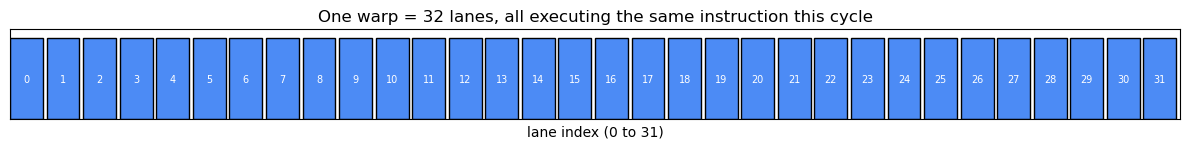

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 1.6))

for lane in range(32):
    ax.add_patch(plt.Rectangle((lane, 0), 0.9, 0.9, facecolor="#4c8bf5", edgecolor="black"))
    ax.text(lane + 0.45, 0.45, str(lane), ha="center", va="center", color="white", fontsize=7)

ax.set_xlim(0, 32)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title("One warp = 32 lanes, all executing the same instruction this cycle")
ax.set_xlabel("lane index (0 to 31)")
plt.tight_layout()
plt.show()

## 2. What the branch does

Each thread computes its position in the warp:

`int lane = threadIdx.x % 32`

This gives a value from 0 to 31. Then the kernel branches on it:

`if (lane & 0xF0F0F0F0)`

The `&` is a bitwise AND. A bit in the result is set only if it is set in both `lane` and `0xF0F0F0F0`.

Since `lane` is only ever 0 to 31, it uses just the low 5 bits, and the highest of those is bit 4 (value 16). The lowest byte of `0xF0F0F0F0` is `0xF0`, which is `11110000`, so it has bits 4, 5, 6, and 7 set. The only bit they share is bit 4.

So `lane & 0xF0F0F0F0` is non-zero only when bit 4 of lane is set, which means **lane 16 or higher**.

Result: lanes 16 to 31 take the branch and do the work. Lanes 0 to 15 skip it. Half the warp goes one way, half goes the other. That split inside a single warp is **warp divergence**.

In [3]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(12, 1.8))
ax.set_xlim(0, 32); ax.set_ylim(0, 1)
ax.set_xticks([]); ax.set_yticks([])

rects, labels = [], []
for lane in range(32):
    r = plt.Rectangle((lane, 0), 0.9, 0.9, edgecolor="black")
    ax.add_patch(r); rects.append(r)
    labels.append(ax.text(lane + 0.45, 0.45, str(lane), ha="center", va="center", fontsize=7))

ACTIVE = "#2ecc71"   # green = executing
MASKED = "#bdc3c7"   # grey = masked off

def draw(active_high):
    for lane in range(32):
        on = (lane >= 16) if active_high else (lane < 16)
        rects[lane].set_facecolor(ACTIVE if on else MASKED)
        labels[lane].set_color("black" if on else "#7f8c8d")
    half = "lanes 16 to 31" if active_high else "lanes 0 to 15"
    ax.set_title(f"Divergence: warp executes {half} now, the other half is masked")

def update(frame):
    draw(frame % 2 == 0)
    return rects + labels

anim = animation.FuncAnimation(fig, update, frames=4, interval=900, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## 3. Divergence wastes work: execution efficiency

Look at what the animation showed. The warp cannot run both halves at once, so it runs them one after the other. Each pass, half the lanes are masked off: powered on and occupying the warp, but their results thrown away.

    lane:   0 1 2 3 4 5 6 7 ... 15   16 17 18 ... 31

    pass 1  . . . . . . . .  .  .    #  #  #   .. #     (lanes 16-31 active)
    pass 2  # # # # # # # #  #  #    .  .  .   .. .     (lanes 0-15 active)

    # = active (doing work)     . = masked (idle, result discarded)

Either pass, only 16 of 32 lanes do useful work. The warp runs at half capacity.

This is measured by **warp execution efficiency**: the average fraction of lanes active while the warp runs. All 32 active is 100 percent. This divergent kernel sits around 50 percent, because half the lanes are masked through the branch.

The thing to hold onto: divergence wastes the lanes *inside* a warp. It is a per-warp, lane-level cost. It says nothing yet about how many warps are on the GPU.

## 4. Occupancy is a different thing entirely

Everything above was about lanes *inside* one warp. Occupancy is about *how many warps* are on the hardware.

An SM (**streaming multiprocessor**) can hold a fixed maximum number of warps resident at once. On this A4000 that number is 48 per SM. 

**Achieved occupancy** is the average number of warps actually resident and active, divided by that maximum.

Here is the part the question is built around: a masked-off lane does not remove its warp from the SM. A warp running with only 16 of 32 lanes active is still a fully resident warp. It still occupies its slot. It still counts as one active warp for occupancy.

So divergence and occupancy move independently:

    warp execution efficiency  ->  how full each warp is   (lanes active / 32)
    achieved occupancy         ->  how full the SM is      (warps resident / 48)

Masking lanes changes the first number. It does not touch the second. A kernel can be 50 percent efficient and still have high occupancy, or be 100 percent efficient with terrible occupancy. They measure different things.

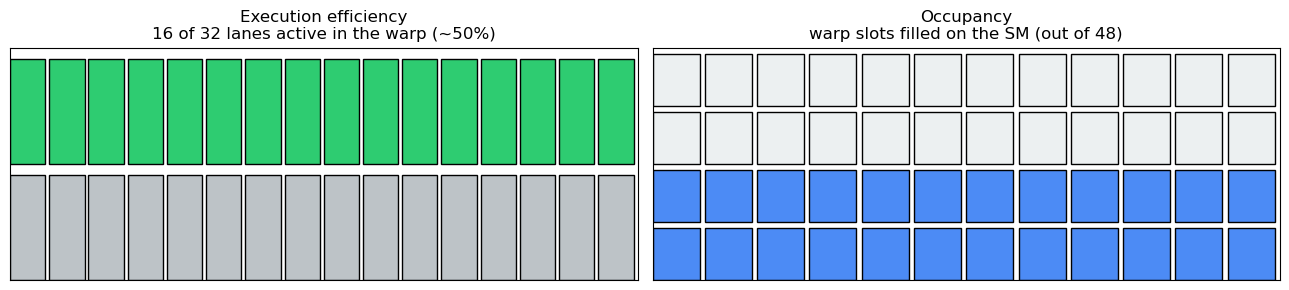

In [5]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))

# LEFT: one warp, lane-level efficiency (16 of 32 active)
for lane in range(32):
    active = lane >= 16
    ax1.add_patch(plt.Rectangle((lane % 16, lane // 16), 0.9, 0.9,
                  facecolor="#2ecc71" if active else "#bdc3c7", edgecolor="black"))
ax1.set_xlim(0, 16); ax1.set_ylim(0, 2)
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_title("Execution efficiency\n16 of 32 lanes active in the warp (~50%)")

# RIGHT: one SM, warp-level occupancy (48 slots, the warp is resident)
for slot in range(48):
    resident = slot < 24   # illustrative: some slots filled
    ax2.add_patch(plt.Rectangle((slot % 12, slot // 12), 0.9, 0.9,
                  facecolor="#4c8bf5" if resident else "#ecf0f1", edgecolor="black"))
ax2.set_xlim(0, 12); ax2.set_ylim(0, 4)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title("Occupancy\nwarp slots filled on the SM (out of 48)")

plt.tight_layout()
plt.show()

## 5. What actually determines occupancy

If divergence does not lower occupancy, what does? Occupancy is set by how many warps the hardware can keep resident, and that is limited by the launch configuration and the resources each block uses:

- **Threads per block (block size).** Warps come from blocks. If blocks are tiny, you may not have enough warps to fill the SM's 48 slots. If the grid launches too few threads total, most slots sit empty.
- **Registers per thread.** Each SM has a fixed **register file**. If each thread uses many registers, fewer threads (and fewer warps) fit at once.
- **Shared memory per block.** Same idea. An SM has limited **shared memory**. Heavy use per block means fewer blocks resident, so fewer warps.
- **Total work launched (grid size).** If the grid is small relative to the GPU, there simply are not enough warps to go around, so **achieved occupancy** stays low regardless of anything inside the kernel.

The mask in the question, **`0xF0F0F0F0`**, touches none of these. It only changes which lanes are active inside warps that are already resident. That makes it a **warp divergence** problem, which is an **execution efficiency** issue, not an occupancy one. Occupancy is governed by the **launch configuration** and **per-thread resource use** instead.


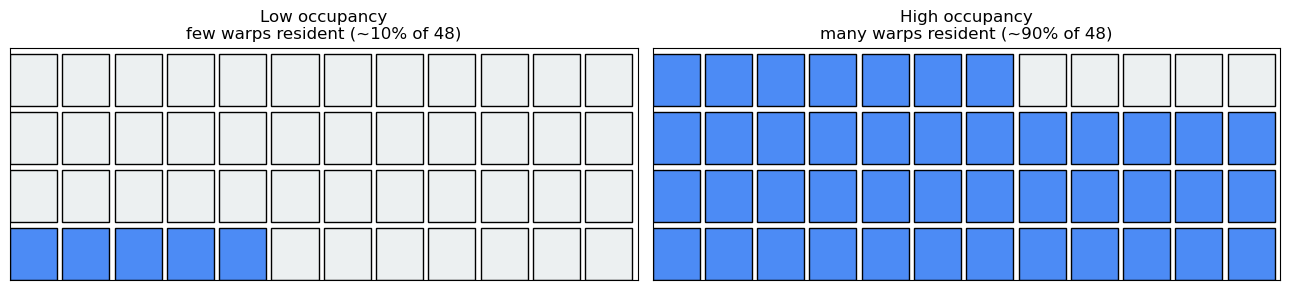

In [6]:
import matplotlib.pyplot as plt

def draw_sm(ax, filled, title):
    for slot in range(48):
        on = slot < filled
        ax.add_patch(plt.Rectangle((slot % 12, slot // 12), 0.9, 0.9,
                     facecolor="#4c8bf5" if on else "#ecf0f1", edgecolor="black"))
    ax.set_xlim(0, 12); ax.set_ylim(0, 4)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3))
draw_sm(ax1, 5,  "Low occupancy\nfew warps resident (~10% of 48)")
draw_sm(ax2, 43, "High occupancy\nmany warps resident (~90% of 48)")
plt.tight_layout()
plt.show()

## Recap

Two separate measurements, often confused.

**Warp execution efficiency** is how many of a warp's 32 lanes are active. It is lowered by **warp divergence**, when threads in a warp take different branches. It is a per-warp, lane-level cost.

**Achieved occupancy** is how many warps are resident on an SM, out of its maximum, which is 48 on this A4000. It is determined by **launch configuration and per-thread resource use**: block size, registers per thread, shared memory per block, and total work launched.

They move independently. Masking lanes changes efficiency, not occupancy. A warp with idle lanes is still a resident warp.

Takeaway: when a kernel's occupancy is low, look at the launch configuration and resource usage, not at divergence inside the warps.

## Recap

Two separate measurements, often confused:

- **Warp execution efficiency**: how many of a warp's 32 lanes are active. Lowered by **warp divergence**, when threads in a warp take different branches. A per-warp, lane-level cost.
- **Achieved occupancy**: how many warps are resident on an SM, out of its maximum (48 on this A4000). Determined by **launch configuration and per-thread resource use**: block size, registers per thread, shared memory per block, and total work launched.

They move independently. Masking lanes changes efficiency, not occupancy. A warp with idle lanes is still a resident warp.

Takeaway: when a kernel's occupancy is low, look at the launch configuration and resource usage, not at divergence inside the warps.